# Chapter 11 -  Modelling time series with vanilla RNN

In [ ]:
import sys
sys.path.append('../')
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, Subset
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

from timeseries import normalize_series
from Chapter10.utils import create_sliding_windows, plot_training, plot_prediction
from Chapter10.models import train, predict, TimeSeriesRNN

## Data

In [6]:
def get_data():
    data_file = "station.csv"
    f = open(data_file)
    data = f.read()
    f.close()
    lines = data.split('\n')
    header = lines[0].split(',')
    lines = lines[1:]
    temperatures=[]
    for line in lines:
        if line:
            linedata = line.split(',')
            linedata = linedata[1:13]
            for item in linedata:
                if item:
                    temperatures.append(float(item))

    series = np.asarray(temperatures)
    time = np.arange(len(temperatures), dtype="float32")
    return time, series

In [ ]:
# load and normalize time series
time, series = get_data()
series_normalized = normalize_series(series)
print(f'{len(series_normalized)} time steps')

897 time steps


### Create samples

In [3]:
window_size = 48

series_tensor = torch.tensor(series_normalized, dtype=torch.float32)
features, targets = create_sliding_windows(series_tensor, window_size=window_size, shift=1)

### `DataLoader`

Original series length: 897
Total number of windows: 850
Training windows: 753
Validation windows: 97

Example Training Batch:
Batch shape - Features: torch.Size([64, 1, 47]), Targets: torch.Size([64, 1])

Example Validation Batch:
Batch shape - Features: torch.Size([64, 1, 47]), Targets: torch.Size([64, 1])


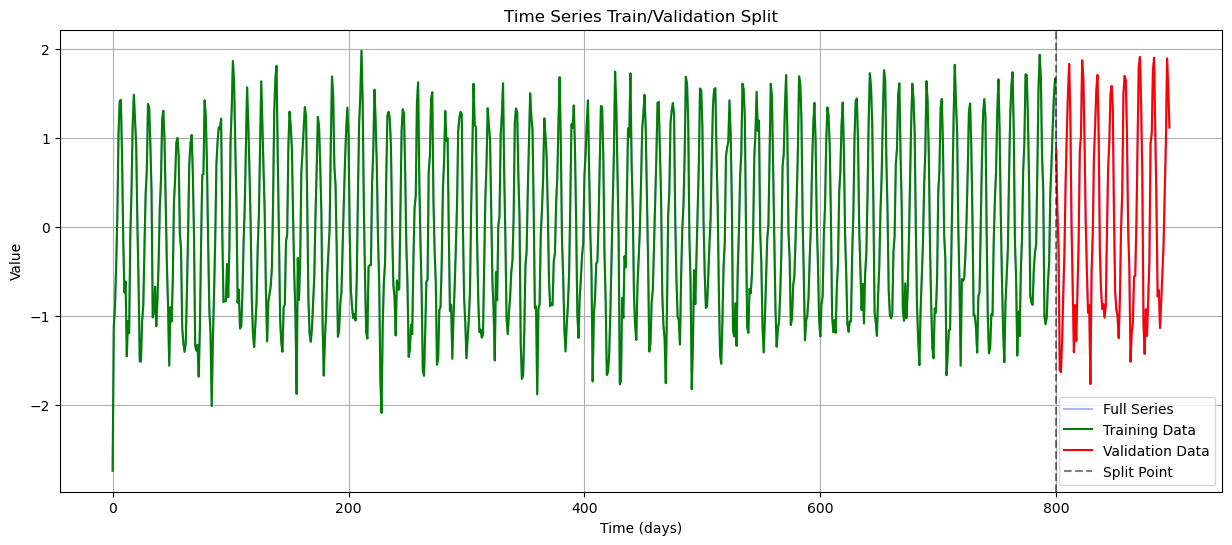

In [4]:
split_location = 800
batch_size = 64

features = features.unsqueeze(1)

# Create the full dataset
full_dataset = TensorDataset(features, targets)

# Calculate split indices
# Note: Since we're using windows, we need to account for the overlap
train_size = split_location - window_size + 1  # Adjust for window overlap
total_windows = len(full_dataset)
train_indices = list(range(train_size))
val_indices = list(range(train_size, total_windows))

# Create training and validation datasets using Subset
train_dataset = Subset(full_dataset, train_indices)
val_dataset = Subset(full_dataset, val_indices)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# Print information about the splits
print(f"Original series length: {len(series_normalized)}")
print(f"Total number of windows: {total_windows}")
print(f"Training windows: {len(train_dataset)}")
print(f"Validation windows: {len(val_dataset)}")

# Show example batch from each
print("\nExample Training Batch:")
train_features, train_targets = next(iter(train_loader))
print(f"Batch shape - Features: {train_features.shape}, Targets: {train_targets.shape}")

print("\nExample Validation Batch:")
val_features, val_targets = next(iter(val_loader))
print(f"Batch shape - Features: {val_features.shape}, Targets: {val_targets.shape}")

# Visualize the split point
plt.figure(figsize=(15, 6))
plt.plot(range(len(series_normalized)), series_normalized, 'b-', label='Full Series', alpha=0.3)
plt.plot(range(split_location), series_normalized[:split_location], 'g-', label='Training Data')
plt.plot(range(split_location, len(series_normalized)), series_normalized[split_location:], 'r-', label='Validation Data')
plt.axvline(x=split_location, color='k', linestyle='--', alpha=0.5, label='Split Point')
plt.title('Time Series Train/Validation Split')
plt.xlabel('Time (days)')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

## Model

### Simple RNN

Train loader batch shape:
Features shape: torch.Size([64, 1, 47])
Targets shape: torch.Size([64, 1])
Using input size: 1


/home/casadoj/miniconda3/envs/torch/lib/python3.12/site-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(


Epoch [100 / 500], Train Loss: 0.0654, Val Loss: 0.0701
Early stopping tiggered after 119 epochs


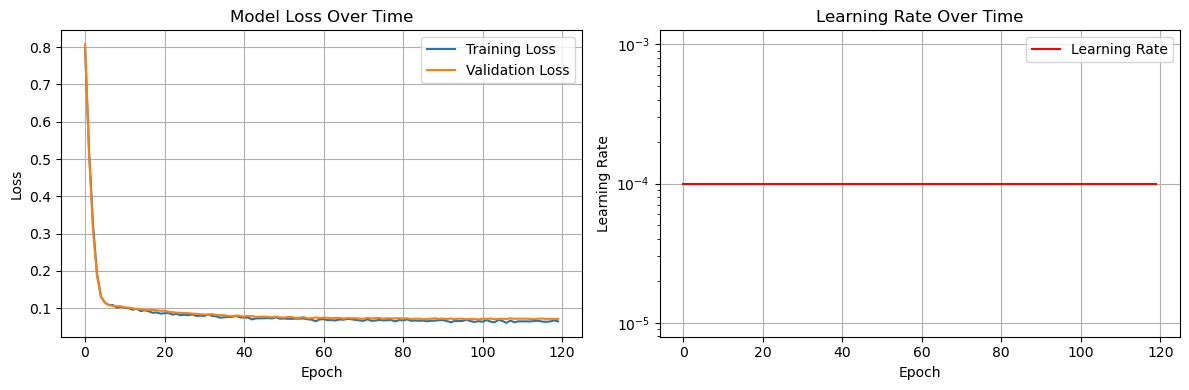

Train predictions shape:	 torch.Size([753, 1])
Validation predictions shape:	 torch.Size([97, 1])


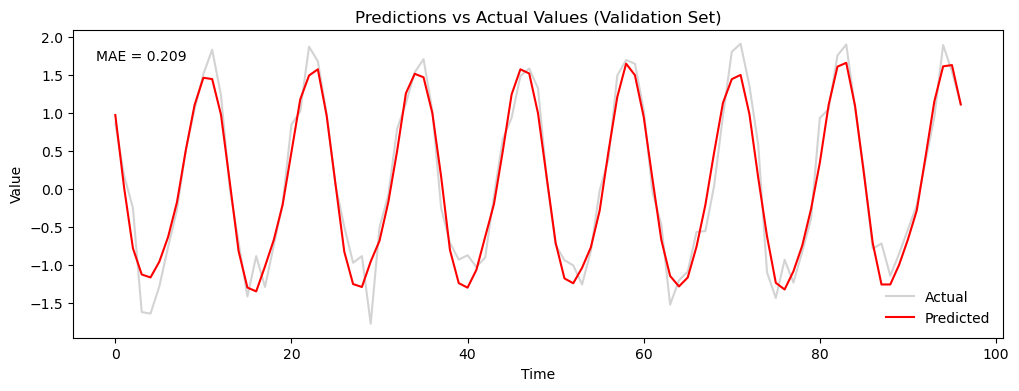

In [5]:
num_epochs = 500
learning_rate = 0.0001

if __name__ == "__main__":
    # Debug prints
    print("Train loader batch shape:")
    sample_batch = next(iter(train_loader))
    print("Features shape:", sample_batch[0].shape)
    print("Targets shape:", sample_batch[1].shape)

    # Initialize model with sequence length
    input_size = sample_batch[0].shape[1]  # Get sequence length from data
    print(f"Using input size: {input_size}")
    model = TimeSeriesRNN(window_size - 1).to(device)

    # Train the model
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    model, loss, history = train(
        model, 
        train_loader, 
        val_loader, 
        criterion, 
        optimizer, 
        epochs=num_epochs, 
        patience=20
        )
    plot_training(history['train_loss'], history['val_loss'], history['learning_rates'])

    # Prediction
    train_predictions, _ = predict(model, train_loader)
    print("Train predictions shape:\t", train_predictions.shape)
    val_predictions, val_targets = predict(model, val_loader)
    print("Validation predictions shape:\t", val_predictions.shape)
    plot_prediction(val_predictions, val_targets)